In [1]:
import numpy as np
import pandas as pd
from qiskit.circuit.library import ZZFeatureMap
from qiskit.quantum_info import Statevector

# Load dataset
column_names = ['ID', 'Diagnosis'] + [f'feature_{i}' for i in range(1, 31)]
data = pd.read_csv("wdbc.data", names=column_names)
data['Diagnosis'] = data['Diagnosis'].map({'M': 1, 'B': 0})

X = data.drop(['ID', 'Diagnosis'], axis=1).values
y = data['Diagnosis'].values

# Standardize
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X_scaled = (X - X_mean) / X_std

# PCA → 6 components
U, S, Vt = np.linalg.svd(X_scaled, full_matrices=False)
X_pca = X_scaled @ Vt.T[:, :6]


In [2]:
np.random.seed(42)
idx = np.random.permutation(len(X_pca))
X_pca = X_pca[idx]
y = y[idx]

split = int(0.8 * len(X_pca))
X_train = X_pca[:split]
X_test  = X_pca[split:]
y_train = y[:split]
y_test  = y[split:]


In [3]:
mins = X_train.min(axis=0)
maxs = X_train.max(axis=0)

def scale_pi(X):
    return (X - mins) / (maxs - mins) * np.pi

X_train = scale_pi(X_train)
X_test  = scale_pi(X_test)


In [4]:
feature_map = ZZFeatureMap(
    feature_dimension=6,
    reps=5,
    entanglement='full'
)

def quantum_kernel(x1, x2):
    c1 = feature_map.assign_parameters({p:v for p,v in zip(feature_map.parameters, x1)})
    c2 = feature_map.assign_parameters({p:v for p,v in zip(feature_map.parameters, x2)})

    sv1 = Statevector.from_instruction(c1)
    sv2 = Statevector.from_instruction(c2)

    return np.abs(np.vdot(sv1, sv2))**2


In [5]:
n_train = len(X_train)
K_train = np.zeros((n_train, n_train))
for i in range(n_train):
    for j in range(n_train):
        K_train[i, j] = quantum_kernel(X_train[i], X_train[j])

n_test = len(X_test)
K_test = np.zeros((n_test, n_train))
for i in range(n_test):
    for j in range(n_train):
        K_test[i, j] = quantum_kernel(X_test[i], X_train[j])


In [6]:
# Regularization parameter
lam = 1e-2

# Convert labels to {-1, +1}
y_train_pm = 2*y_train - 1

# Solve (K + λI)α = y
alpha = np.linalg.solve(
    K_train + lam * np.eye(n_train),
    y_train_pm
)

# Predictions
y_pred = np.sign(K_test @ alpha)
y_pred[y_pred == -1] = 0


In [8]:
# Convert labels to {-1, +1}
y_train_pm = 2*y_train - 1

# Compute class-wise kernel means
K_pos = K_train[y_train == 1]   # malignant
K_neg = K_train[y_train == 0]   # benign

mean_pos = K_pos.mean(axis=0)
mean_neg = K_neg.mean(axis=0)

# Predict
y_pred = []

for i in range(len(K_test)):
    score_pos = np.dot(K_test[i], mean_pos)
    score_neg = np.dot(K_test[i], mean_neg)
    y_pred.append(1 if score_pos > score_neg else 0)

y_pred = np.array(y_pred)

accuracy = np.mean(y_pred == y_test)
print("QSVM Accuracy =", accuracy)


QSVM Accuracy = 0.5964912280701754


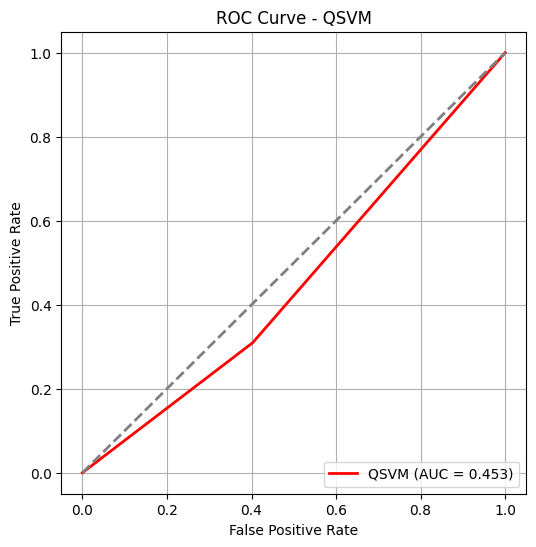

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# --- Step 1: Predict probabilities ---
# QSVM usually outputs labels, so we simulate probability as [1-p, p]
# If your QSVM supports decision_function, we can map it to probability
y_pred = clf.predict(test_kernel)

# Convert to probability-like values (for binary classification)
# Here: treat prediction as "hard" probability
y_proba = np.array(y_pred, dtype=float)

# If needed, reshape into proper probability format
# (N, 2) with columns [P(class 0), P(class 1)]
y_proba = np.vstack([1 - y_proba, y_proba]).T

# --- Step 2: ROC Curve ---
fpr, tpr, thresholds = roc_curve(y_test, y_proba[:, 1])  # prob for class 1
roc_auc = auc(fpr, tpr)

# --- Step 3: Plot ---
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color="red", lw=2, label=f"QSVM (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], color="gray", lw=2, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - QSVM")
plt.legend(loc="lower right")
plt.grid()
plt.show()
